In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Carregando dados 
url = "https://raw.githubusercontent.com/vbomura/tc5/main/Codigos/base_anos_limpo.xlsx"
dfBaseAnosLimpos = pd.read_excel(url)

In [33]:
# Definição das colunas de entrada (features) e do alvo (target)
#features = ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv']
features = ['idade','ian', 'ida', 'ieg', 'ipp', 'ipv']
target = 'defasagem'

In [34]:
dfBaseAnosLimpos

,ra,fase,turma,nome_anonimizado,ano_nasc_original,idade_original,genero,ano_ingresso,instituicao_de_ensino,pedra,...,ipv,ian,fase_ideal_original,defasagem,ano_aba,ano_nascimento,fase_ideal,ipp,fase_original,idade
0,RA-1,7,A,Aluno-1,2003,19,Feminino,2016,Escola Pública,Quartzo,...,7.278,5.0,Fase 8 (Universitários),-1,2022,2003,FASE 8,NaN,NaN,19
1,RA-2,7,A,Aluno-2,2005,17,Feminino,2017,Rede Decisão,Ametista,...,6.778,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
2,RA-3,7,A,Aluno-3,2005,17,Feminino,2016,Rede Decisão,Ágata,...,7.556,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
3,RA-4,7,A,Aluno-4,2005,17,Masculino,2017,Rede Decisão,Quartzo,...,5.278,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
4,RA-5,7,A,Aluno-5,2005,17,Feminino,2016,Rede Decisão,Ametista,...,7.389,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,RA-291,FASE 7,7E,Aluno-291,2009-01-17 00:00:00,15,Masculino,2022,Privada - Programa de Apadrinhamento,Ametista,...,7.500,10.0,Fase 5 (1° EM),2,2024,2009,FASE 5,7.5,7E,15
2841,RA-86,FASE 7,7E,Aluno-86,2006-10-04 00:00:00,18,Masculino,2021,Privada *Parcerias com Bolsa 100%,Ametista,...,7.500,10.0,Fase 7 (3° EM),0,2024,2006,FASE 7,7.5,7E,18
2842,RA-143,FASE 7,7E,Aluno-143,2009-08-01 00:00:00,15,Masculino,2021,Privada - Programa de Apadrinhamento,Ametista,...,7.500,10.0,Fase 5 (1° EM),2,2024,2009,FASE 5,7.5,7E,15
2843,RA-166,FASE 7,7E,Aluno-166,2008-06-03 00:00:00,16,Masculino,2021,Privada *Parcerias com Bolsa 100%,Topázio,...,7.500,10.0,Fase 6 (2° EM),1,2024,2008,FASE 6,7.5,7E,16


In [35]:
# Verificando se existem valores nulos e removendo-os
df_model = dfBaseAnosLimpos[features + [target]].dropna()

df_model

,idade,ian,ida,ieg,ipp,ipv,defasagem
860,8,10.0,9.600000,10.000000,8.4375,8.920,0
861,9,5.0,8.900000,9.100000,7.5000,8.585,-1
862,7,10.0,6.300000,7.600000,5.9375,6.260,0
863,8,10.0,6.300000,7.600000,7.5000,8.500,0
864,9,10.0,7.400000,8.700000,7.5000,7.915,0
...,...,...,...,...,...,...,...
2840,15,10.0,6.166667,9.737667,7.5000,7.500,2
2841,18,10.0,5.483333,9.704333,7.5000,7.500,0
2842,15,10.0,2.633333,9.920000,7.5000,7.500,2
2843,16,10.0,8.266667,9.246000,7.5000,7.500,1


In [36]:
X = df_model[features]
y = df_model[target]

# Separando em treino/teste 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

print("\n--- Acurácia ---")
print(f"{accuracy_score(y_test, y_pred):.2%}")


--- Relatório de Classificação ---
              precision    recall  f1-score   support

          -3       1.00      1.00      1.00         3
          -2       0.58      0.19      0.29        36
          -1       0.85      0.97      0.90       166
           0       0.87      0.97      0.92       164
           1       0.20      0.04      0.07        24
           2       0.20      0.50      0.29         2
           3       0.00      0.00      0.00         2

    accuracy                           0.84       397
   macro avg       0.53      0.53      0.50       397
weighted avg       0.79      0.84      0.80       397


--- Acurácia ---
83.63%


d:\PosFIAP\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\PosFIAP\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\PosFIAP\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


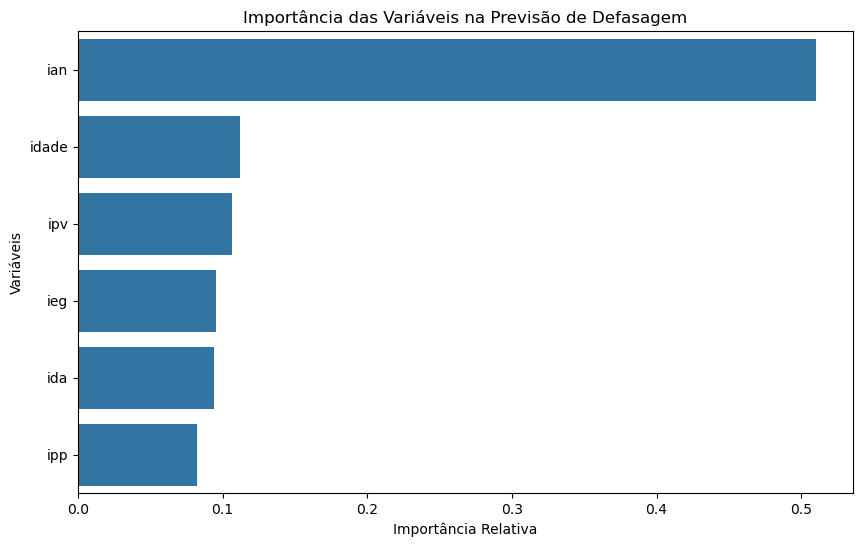

In [37]:
#Visualização da Importância das Variáveis
feature_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Importância das Variáveis na Previsão de Defasagem')
plt.xlabel('Importância Relativa')
plt.ylabel('Variáveis')
plt.show()

In [38]:
import joblib
#Criando joblib da predição
#joblib.dump(model,'RandomForest.joblib')